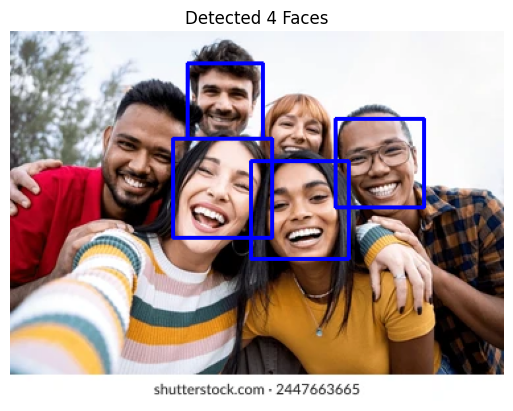

Number of faces detected: 4


In [5]:
import cv2
import matplotlib.pyplot as plt

def count_faces(image_path):
    """
    Counts the number of faces in an image using OpenCV's Haar Cascade classifier.

    Args:
        image_path (str): The path to the input image.

    Returns:
        int: The number of faces detected in the image.
    """
    # Load the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Load the Haar Cascade classifier for face detection
    # You might need to download this XML file if you don't have it.
    # It's usually found in your OpenCV installation directory under 'haarcascades'.
    # Example path: cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    face_cascade = cv2.CascadeClassifier(face_cascade_path)

    if face_cascade.empty():
        print(f"Error: Could not load face cascade from {face_cascade_path}")
        print("Please ensure the XML file is present and the path is correct.")
        return 0

    # Detect faces in the image
    # The detectMultiScale function detects objects of different sizes in the input image.
    # The detected objects are returned as a list of rectangles.
    # scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
    # minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around the faces for visualization (optional)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Display the image with detected faces (optional)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected {len(faces)} Faces')
    plt.axis('off')
    plt.show()

    return len(faces)

# Example Usage:
# You need to replace 'path/to/your/image.jpg' with the actual path to an image file.
# You can upload an image to your Colab environment or provide a URL.
# For example, let's create a dummy image for demonstration if no image is provided.

# Create a dummy image for demonstration if no actual image is available
import numpy as np
import os

dummy_image_path = '/tmp/dummy_people.jpg'
if not os.path.exists(dummy_image_path):
    # Create a simple image (e.g., a white image) to avoid errors if no real image is provided
    dummy_img = np.zeros((300, 400, 3), dtype=np.uint8) # Black image
    cv2.putText(dummy_img, 'No Faces Detected Here', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_img)
    print(f"Created a dummy image at {dummy_image_path}. Please replace with your own image for face detection.")

# Replace with your actual image path
image_file = '/content/human faces.webp'

num_faces = count_faces(image_file)
print(f"Number of faces detected: {num_faces}")


In [2]:
import os
import cv2

face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

if os.path.exists(face_cascade_path):
    print(f"The Haar Cascade XML file exists at: {face_cascade_path}")
else:
    print(f"Error: The Haar Cascade XML file was NOT found at: {face_cascade_path}")
    print("Please ensure OpenCV is correctly installed or download the file manually and provide the correct path.")


The Haar Cascade XML file exists at: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml
